전처리

In [242]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. 데이터 로드
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATA/train_titanic.csv')
X_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATA/test_titanic.csv') # 원본 보존용
X_test_passengers = X_test['PassengerId']


In [243]:
print(dataset.isna().sum(), '\n')
print(X_test.isna().sum())
X_test.head()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64 

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [246]:
dataset.dropna(axis = 0, subset = 'Embarked', inplace = True)

In [247]:
X_sum = pd.concat([dataset.drop('Survived', axis = 1).copy(), X_test])
X_sum.isna().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,263
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,1014


In [248]:
def get_title(df):
    titles = [i.split(',')[1].split('.')[0].strip() for i in df['Name']]
    df['Title'] = pd.Series(titles)
    df['Title'] = df['Title'].replace(['Lady', 'the Countess', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona', 'Ms', 'Mme', 'Mlle'], 'Rare')
    return df

X_sum = get_title(X_sum)

In [249]:
X_sum['FamilyS'] = X_sum['SibSp'] + X_sum['Parch'] + 1

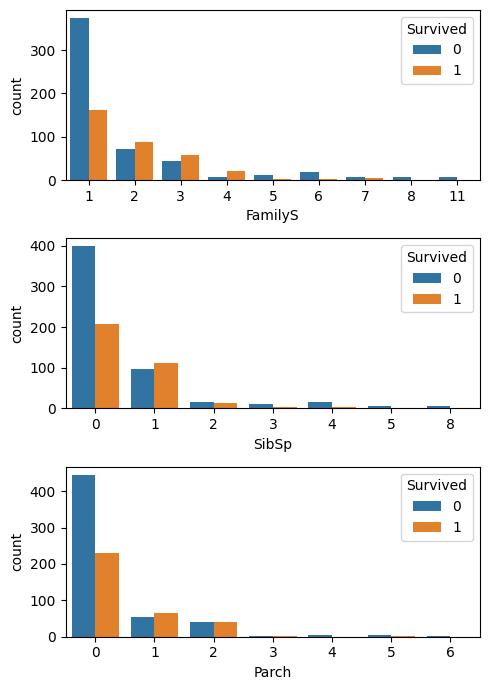

In [250]:
import matplotlib.pyplot as plt
import seaborn as sns
dataset = get_title(dataset)
dataset['FamilyS'] = dataset['SibSp'] + dataset['Parch'] + 1
fam_feats=['FamilyS', 'SibSp', 'Parch']

# Plot categorical features
fig=plt.figure(figsize=(5,7))
for i, var_name in enumerate(fam_feats):
    ax=fig.add_subplot(3,1,i+1)
    sns.countplot(data=dataset, x=var_name, axes=ax, hue='Survived')
fig.tight_layout()  # Improves appearance a bit
plt.show()

# FamilyS -> 1, 2-4, 5-
# SibSp -> 0, 1, 2, 3-
# parch -> 0, 1-3, 4-
# 과적합 위험은 있는거같음

In [251]:
print(X_sum.value_counts('SibSp'))
print(X_sum.groupby(['SibSp','Parch'])['Age'].median().fillna(0))

SibSp
0    889
1    319
2     42
4     22
3     20
8      9
5      6
Name: count, dtype: int64
SibSp  Parch
0      0        29.0
       1        25.0
       2        24.0
       3        30.0
       4        29.0
       5        40.0
1      0        30.0
       1        27.0
       2        24.0
       3        48.0
       4        52.5
       5        39.0
       6        41.5
       9         0.0
2      0        25.0
       1         5.0
       2        18.0
       3        24.0
3      0        31.0
       1         6.0
       2        14.5
4      1         7.0
       2         7.5
5      2        10.5
8      2        14.5
Name: Age, dtype: float64


In [252]:
# 3. FamilySize 및 IsAlone 생성
for df in [X_sum]:
    df['FamilyS'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilyS'] == 1).astype(int)
    # 가족 규모 그룹화 (1:혼자, 2~4:적당함, 5+:많음)
    df['FamilyS'] = df['FamilyS'].apply(lambda x: 0 if x == 1 else (1 if x <= 4 else 2))
    df['SibSp'] = df['SibSp'].apply(lambda x : 0 if x == 1 else (2 if x == 2 else ( 3 if x == 3 else 4)))
    df['Parch'] = df['Parch'].apply(lambda x : 0 if x == 1 else (2 if x <= 3 else 3))



In [253]:
X_sum['Fare'] = np.log(1 + X_sum['Fare'])

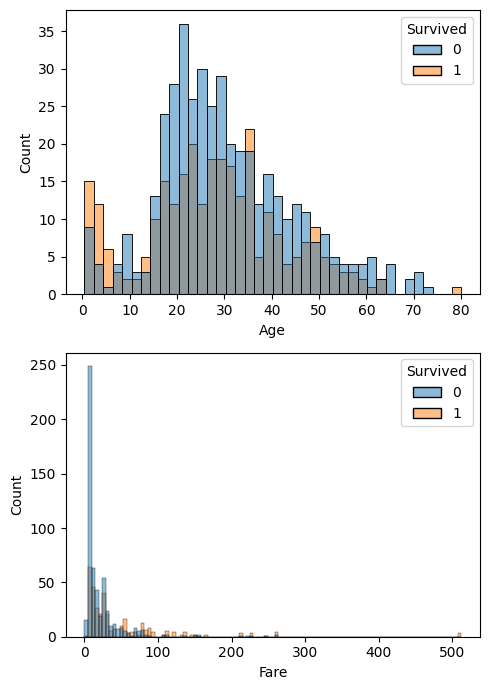

In [256]:
import matplotlib.pyplot as plt
import seaborn as sns

dataset = get_title(dataset)
fam_feats=['Fare', 'Age']

# Plot categorical features
fig=plt.figure(figsize=(5,7))
ax=fig.add_subplot(2,1,1)
sns.histplot(data=dataset, x='Age', binwidth = 2,axes=ax, hue='Survived')
ax=fig.add_subplot(2,1,2)
sns.histplot( x=dataset['Fare'],  axes=ax,  hue=dataset['Survived'])

fig.tight_layout()  # Improves appearance a bit
plt.show()
#2.095, 3.981

In [257]:
print(dataset[(2.0 < dataset['Fare']) & (dataset['Fare'] < 2.2)].groupby(['Fare', 'Survived']).size())
print(dataset[(3.9 < dataset['Fare']) & (dataset['Fare'] < 4.1)].groupby(['Fare', 'Survived']).size())

Series([], dtype: int64)
Fare    Survived
4.0125  0           1
dtype: int64


In [258]:
print(dataset[(0.0 < dataset['Age']) & (dataset['Age'] < 10.2)].groupby(['Age', 'Survived']).size())
#print(dataset[(3.9 < dataset['Age']) & (dataset['Age'] < 4.1)].groupby(['Age', 'Survived']).size())
# 0.99, 8.5, 20, 34, 65

Age    Survived
0.42   1           1
0.67   1           1
0.75   1           2
0.83   1           2
0.92   1           1
1.00   0           2
       1           5
2.00   0           7
       1           3
3.00   0           1
       1           5
4.00   0           3
       1           7
5.00   1           4
6.00   0           1
       1           2
7.00   0           2
       1           1
8.00   0           2
       1           2
9.00   0           6
       1           2
10.00  0           2
dtype: int64


In [259]:
X_sum.drop('Cabin', axis = 1, inplace = True)

In [261]:
print(X_temp.value_counts(['Title', 'Age']))

Title   Age
Mr      3      279
        2      100
        4       98
Miss    3       91
Mrs     3       60
Miss    4       57
Mr      5       55
Mrs     4       40
Miss    2       36
Mr      1       33
Mrs     2       25
Mr      6       23
Miss    5       14
        1       14
Master  2       13
Mrs     5       11
Master  3       11
        4       11
Rare    3       10
Mr      0        9
Miss    6        9
Master  1        7
Rare    4        7
        5        6
Mrs     6        6
Master  5        4
Mrs     1        4
Rare    2        2
Miss    0        2
Rare    6        2
        1        2
Master  6        1
Mrs     0        1
Name: count, dtype: int64


In [262]:
import numpy as np

# 4. 결측치 채우기 (학습 데이터 기준 적용)
# Title별 Age 최빈값으로 Age 결측치 채우기 (한 줄로)
X_sum['Age'] = X_sum['Age'].fillna(X_sum.groupby('Title')['Age'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

In [263]:
print(X_sum.isna().sum())

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
Title          0
FamilyS        0
IsAlone        0
dtype: int64


In [264]:
X_temp[['Pclass', 'Fare']].sort_values(by=['Pclass', 'Fare']).value_counts()

Pclass  Fare
3       1       463
2       1       249
1       2       178
        1        99
3       0        32
2       2        12
1       0         5
3       2         5
Name: count, dtype: int64

In [265]:
print(X_sum[X_sum.isna().any(axis=1)])

     PassengerId  Pclass                Name   Sex   Age  SibSp  Parch Ticket  \
152         1044       3  Storey, Mr. Thomas  male  60.5      4      2   3701   

     Fare Embarked Title  FamilyS  IsAlone  
152   NaN        S    Mr        0        1  


In [266]:
X_sum['Fare'].fillna(3.5, inplace = True)

/tmp/ipython-input-584272260.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_sum['Fare'].fillna(3.5, inplace = True)


In [267]:
X_sum.dropna(axis = 0, inplace = True)

In [268]:
# 5. Fare & Age 구간 나누기 (Binning) - 무한대 범위 확장으로 에러 방지
fare_bins = [-np.inf, 2.095, 3.981, np.inf]

age_bins =  [-np.inf, 0.99, 8.5, 20, 34, 47, 58, np.inf]

for df in [X_sum]:
    df['Fare'] = pd.cut(df['Fare'], bins=fare_bins, labels=[0, 1, 2], include_lowest=True).astype(int)
    df['Age'] = pd.cut(df['Age'], bins=age_bins, labels=[0, 1, 2, 3, 4, 5, 6], include_lowest=True).astype(int)


In [269]:
X_sum.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,FamilyS,IsAlone
0,1,3,"Braund, Mr. Owen Harris",male,3,0,2,A/5 21171,1,S,Mr,1,0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,4,0,2,PC 17599,2,C,Mrs,1,0
2,3,3,"Heikkinen, Miss. Laina",female,3,4,2,STON/O2. 3101282,1,S,Miss,0,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,4,0,2,113803,2,S,Mrs,1,0
4,5,3,"Allen, Mr. William Henry",male,4,4,2,373450,1,S,Mr,0,1


In [278]:
# X_sum을 원래의 train/test 데이터셋으로 분리
# dataset은 Survived 컬럼을 가지고 있으므로, X_sum에서 해당 길이만큼 추출
# original `dataset` length is 889 (after dropping Embarked NA)
dataset_processed = X_sum.iloc[:889].copy() # .copy()를 사용하여 SettingWithCopyWarning 방지
X_test_processed_df = X_sum.iloc[889:].copy() # .copy()를 사용하여 SettingWithCopyWarning 방지

# 학습에 사용할 피처 선택
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilyS', 'IsAlone']

# X_train, Y_train, X_test pandas DataFrame 준비 (Label Encoding을 위해 DataFrame 유지)
X_train = dataset_processed[features].copy()
Y_train = dataset['Survived'].values # Original dataset's Survived column
X_test = X_test_processed_df[features].copy()

In [279]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 7. Label Encoding (Sex, Embarked, Title)
# features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilyS', 'IsAlone']

for col_name in ['Sex', 'Embarked', 'Title']: # 문자열 컬럼 이름을 사용하여 DataFrame에 접근
    le = LabelEncoder()
    # X_train과 X_test 모두에 fit_transform을 적용해야 일관성을 유지할 수 있습니다.
    # X_train으로 fit하고 X_test에 transform을 적용합니다.
    X_train[col_name] = le.fit_transform(X_train[col_name])
    X_test[col_name] = le.transform(X_test[col_name])

# 8. ColumnTransformer & OneHotEncoding
# 모든 피처를 범주형으로 취급하여 처리 (sparse_output=False로 toarray 불필요하게 설정)
# 모든 features는 Label Encoding 또는 Binning을 통해 수치형으로 변환되었지만,
# OneHotEncoding을 적용하여 모델이 범주형 특성을 더 잘 학습하도록 할 수 있습니다.
ct = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), list(range(len(features))))
    ],
    remainder='passthrough' # 나머지 컬럼은 그대로 유지 (여기서는 해당 없음)
)

# ColumnTransformer에 DataFrame을 전달하면 내부적으로 처리합니다.
# 결과는 NumPy 배열이므로, .astype(np.float32) 적용
X_train = ct.fit_transform(X_train).astype(np.float32)
X_test = ct.transform(X_test).astype(np.float32)

In [287]:
X_trainn = X_train
X_testt = X_test
Y_trainn = Y_train

선택


In [284]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.2 MB/s eta 0:00:00


In [285]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.naive_bayes import GaussianNB

In [289]:
from sklearn.model_selection import train_test_split

In [304]:
X_train, X_valid, y_train, y_valid = train_test_split(X_trainn,Y_trainn,stratify=Y_trainn,train_size=0.8,test_size=0.2,random_state=0)

classifiers = {
    "LogisticRegression" : LogisticRegression(random_state=0),
    "KNN" : KNeighborsClassifier(),
    "SVC" : SVC(random_state=55, probability=True),
    "RandomForest" : RandomForestClassifier(random_state=0),
    "XGBoost" : XGBClassifier(random_state=55, use_label_encoder=False, eval_metric='logloss'), # XGBoost takes too long
    "LGBM" : LGBMClassifier(random_state=55),
    "CatBoost" : CatBoostClassifier(random_state=55, verbose=False),
    "NaiveBayes": GaussianNB()
}

# Grids for grid search
LR_grid = {'penalty': ['l1','l2'],
           'C': [0.25, 0.5, 0.75, 1, 1.25, 1.5],
           'max_iter': [50, 100, 150]}

KNN_grid = {'n_neighbors': [3, 5, 7, 9],
            'p': [1, 2]}

SVC_grid = {'C': [0.25, 0.5, 0.75, 1, 1.25, 1.5],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']}

RF_grid = {'n_estimators': [50, 100, 150, 200, 250, 300],
        'max_depth': [4, 6, 8, 10, 12]}

boosted_grid = {'n_estimators': [50, 100, 150, 200],
        'max_depth': [4, 8, 12],
        'learning_rate': [0.05, 0.1, 0.15]}

NB_grid={'var_smoothing': [1e-10, 1e-9, 1e-8, 1e-7]}

# Dictionary of all grids
grid = {
    "LogisticRegression" : LR_grid,
    "KNN" : KNN_grid,
    "SVC" : SVC_grid,
    "RandomForest" : RF_grid,
    "XGBoost" : boosted_grid,
    "LGBM" : boosted_grid,
    "CatBoost" : boosted_grid,
    "NaiveBayes": NB_grid
}

In [305]:
import time
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold

In [306]:
i=0
clf_best_params=classifiers.copy()
valid_scores=pd.DataFrame({'Classifer':classifiers.keys(), 'Validation accuracy': np.zeros(len(classifiers)), 'Training time': np.zeros(len(classifiers))})
for key, classifier in classifiers.items():
    start = time.time()
    clf = GridSearchCV(estimator=classifier, param_grid=grid[key], n_jobs=-1, cv=None)

    # Train and score
    clf.fit(X_train, y_train)
    valid_scores.iloc[i,1]=clf.score(X_valid, y_valid)

    # Save trained model
    clf_best_params[key]=clf.best_params_

    # Print iteration and training time
    stop = time.time()
    valid_scores.iloc[i,2]=np.round((stop - start)/60, 2)

    print('Model:', key)
    print('Training time (mins):', valid_scores.iloc[i,2])
    print('')
    i+=1

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
90 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solve

Model: LogisticRegression
Training time (mins): 0.05

Model: KNN
Training time (mins): 0.0

Model: SVC
Training time (mins): 0.09

Model: RandomForest
Training time (mins): 0.75



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:51:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model: XGBoost
Training time (mins): 0.15

[LightGBM] [Info] Number of positive: 272, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000235 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 62
[LightGBM] [Info] Number of data points in the train set: 711, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.382560 -> initscore=-0.478697
[LightGBM] [Info] Start training from score -0.478697
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Model: CatBoost
Training time (mins): 5.88

Model: NaiveBayes
Training time (mins): 0.0



In [307]:
# Show results
valid_scores

,Classifer,Validation accuracy,Training time
0,LogisticRegression,0.859551,0.05
1,KNN,0.820225,0.00
2,SVC,0.853933,0.09
3,RandomForest,0.837079,0.75
4,XGBoost,0.848315,0.15
5,LGBM,0.837079,0.16
6,CatBoost,0.842697,5.88
7,NaiveBayes,0.730337,0.00


In [309]:
clf_best_params

{'LogisticRegression': {'C': 0.25, 'max_iter': 50, 'penalty': 'l2'},
 'KNN': {'n_neighbors': 9, 'p': 1},
 'SVC': {'C': 1.25, 'gamma': 'scale', 'kernel': 'rbf'},
 'RandomForest': {'max_depth': 6, 'n_estimators': 100},
 'XGBoost': {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 50},
 'LGBM': {'learning_rate': 0.05, 'max_depth': 12, 'n_estimators': 50},
 'CatBoost': {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 50},
 'NaiveBayes': {'var_smoothing': 1e-07}}

In [336]:
best_classifiers = {
    "LogisticRegression" : LogisticRegression(**clf_best_params["LogisticRegression"],random_state=55),
    "SVC" : SVC(**clf_best_params["SVC"], random_state=55, probability=True),
    "XGBoost" : XGBClassifier(**clf_best_params["XGBoost"], random_state=55)
}

In [337]:
FOLDS=4

preds=np.zeros(len(X_test))
for key, classifier in best_classifiers.items():
    start = time.time()

    # 10-fold cross validation
    cv = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=0)

    score=0
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_trainn, Y_trainn)):
        # Get training and validation sets
        X_train, X_valid = X_trainn[train_idx], X_trainn[val_idx]
        y_train, y_valid = Y_trainn[train_idx], Y_trainn[val_idx]

        # Train model
        clf = classifier
        clf.fit(X_train, y_train)

        # Make predictions and measure accuracy
        preds += clf.predict_proba(X_test)[:,1]
        score += clf.score(X_valid, y_valid)

    # Average accuracy
    score=score/FOLDS

    # Stop timer
    stop = time.time()

    # Print accuracy and time
    print('Model:', key)
    print('Average validation accuracy:', np.round(100*score,2))
    print('Training time (mins):', np.round((stop - start)/60,2))
    print('')

# Ensemble predictions
preds=preds/(FOLDS*len(best_classifiers))

Model: LogisticRegression
Average validation accuracy: 79.97
Training time (mins): 0.0

Model: SVC
Average validation accuracy: 80.87
Training time (mins): 0.01

Model: XGBoost
Average validation accuracy: 80.88
Training time (mins): 0.0



In [338]:
print(np.round(100*np.round(preds).sum()/len(preds),2))
print(Y_trainn.sum() / len(Y_trainn))

35.65
0.38245219347581555


Optimal threshold: 0.448


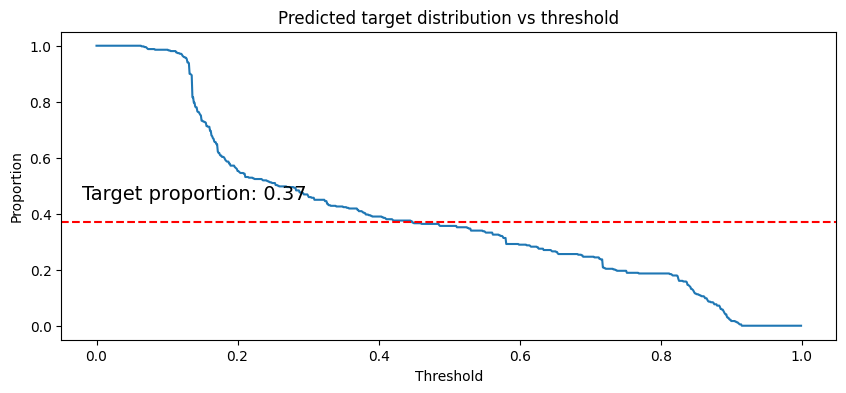

In [340]:
def preds_prop(preds_arr, thresh):
    pred_classes=(preds_arr>=thresh).astype(int)
    return pred_classes.sum()/len(pred_classes)

# Plot proportions across a range of thresholds
def plot_preds_prop(preds_arr):
    # Array of thresholds
    T_array=np.arange(0,1,0.001)

    # Calculate proportions
    prop=np.zeros(len(T_array))
    for i, T in enumerate(T_array):
        prop[i]=preds_prop(preds_arr, T)

    # Plot proportions
    plt.figure(figsize=(10,4))
    plt.plot(T_array, prop)
    target_prop=0.37         # Experiment with this value
    plt.axhline(y=target_prop, color='r', linestyle='--')
    plt.text(-0.02,0.45,f'Target proportion: {target_prop}', fontsize=14)
    plt.title('Predicted target distribution vs threshold')
    plt.xlabel('Threshold')
    plt.ylabel('Proportion')

    # Find optimal threshold (the one that leads to the proportion being closest to target_prop)
    T_opt=T_array[np.abs(prop-target_prop).argmin()]
    print('Optimal threshold:', T_opt)
    return T_opt

T_opt=plot_preds_prop(preds)

In [343]:
import pandas as pd

# Ensemble predictions (preds) is a probability score, convert to binary (0 or 1)
ensemble_predictions = (preds > 0.488).astype(int)

# Create submission DataFrame
submission = pd.DataFrame({
    'PassengerId': X_test_passengers,
    'Survived': ensemble_predictions
})

# Save to CSV
submission_filename = 'submission_ensemble.csv'
submission.to_csv(submission_filename, index=False)

print(f'Ensemble {submission_filename} created successfully!')

# Display the head of the created CSV file
print(f'\nHead of {submission_filename}:')
print(pd.read_csv(submission_filename).head())

#777.51

Ensemble submission_ensemble.csv created successfully!

Head of submission_ensemble.csv:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
